In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import sys

# Notebook uses functions from .py scripts in scripts/ folder
sys.path.append('../scripts/process')

from process import preprocess_data, normalize, remove_empty

## Taxonomic and Pathways Relative Abundances

### Convert raw data from CuratedMetagenomicData

In [3]:
!python ../scripts/convert/convert_cmd.py -i ../data/functions/all/raw/X1.tsv -o ../data/functions/all/converted --data_type functions --chunksize 2000
!python ../scripts/convert/convert_cmd.py -i ../data/functions/all/raw/X2.tsv -o ../data/functions/all/converted --data_type functions --chunksize 2000
!python ../scripts/convert/convert_cmd.py -i ../data/functions/all/raw/X3.tsv -o ../data/functions/all/converted --data_type functions --chunksize 2000
!python ../scripts/convert/convert_cmd.py -i ../data/functions/all/raw/X4.tsv -o ../data/functions/all/converted --data_type functions --chunksize 2000

Processing chunks: 29it [00:21,  1.36it/s]
Processing chunks: 27it [00:20,  1.30it/s]
Processing chunks: 27it [00:20,  1.34it/s]
Processing chunks: 29it [00:23,  1.26it/s]


In [17]:
!python ../scripts/convert/convert_cmd.py -i ../data/genera/all/raw/X1.tsv -o ../data/genera/all/converted --data_type genera --chunksize 2000
!python ../scripts/convert/convert_cmd.py -i ../data/genera/all/raw/X2.tsv -o ../data/genera/all/converted --data_type genera --chunksize 2000
!python ../scripts/convert/convert_cmd.py -i ../data/genera/all/raw/X3.tsv -o ../data/genera/all/converted --data_type genera --chunksize 2000
!python ../scripts/convert/convert_cmd.py -i ../data/genera/all/raw/X4.tsv -o ../data/genera/all/converted --data_type genera --chunksize 2000

Processing chunks: 1it [00:03,  3.48s/it]
Processing chunks: 1it [00:02,  2.88s/it]
Processing chunks: 1it [00:02,  3.00s/it]
Processing chunks: 1it [00:03,  3.25s/it]


### Load pathways abundance data

In [3]:
# Load and preprocess data
X1 = preprocess_data(f'../data/functions/all/converted/X1.tsv')
X2 = preprocess_data(f'../data/functions/all/converted/X2.tsv')
X3 = preprocess_data(f'../data/functions/all/converted/X3.tsv')
X4 = preprocess_data(f'../data/functions/all/converted/X4.tsv')

In [4]:
X_functions = pd.concat([X1, X2, X3, X4], axis=0, ignore_index=False)
print(f"Combined X shape: {X_functions.shape}")

Combined X shape: (20496, 635)


In [5]:
# Fill all NA values with 0
X_functions = X_functions.fillna(0)

# Remove empty rows and columns
X_functions = remove_empty(X_functions)

/tmp/ipykernel_40420/1750867167.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_functions = X_functions.fillna(0)


### Load taxonomic data

In [6]:
# Load and preprocess data
X1 = preprocess_data(f'../data/genera/all/converted/X1.tsv')
X2 = preprocess_data(f'../data/genera/all/converted/X2.tsv')
X3 = preprocess_data(f'../data/genera/all/converted/X3.tsv')
X4 = preprocess_data(f'../data/genera/all/converted/X4.tsv')

In [7]:
X_genera = pd.concat([X1, X2, X3, X4], axis=0, ignore_index=False)
print(f"Combined X shape: {X_genera.shape}")

Combined X shape: (20498, 445)


In [8]:
# Fill all NA values with 0
X_genera = X_genera.fillna(0)

# Remove empty rows and columns
X_genera = remove_empty(X_genera)

/tmp/ipykernel_40420/2769957842.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_genera = X_genera.fillna(0)


In [9]:
# Check if both datasets have the same samples, if not, leave only common samples
common = list(set(X_functions.index) & set(X_genera.index))
X_functions = X_functions.loc[common]
X_genera = X_genera.loc[common]

X_functions.shape, X_genera.shape

((20455, 623), (20455, 430))

In [10]:
X_genera = normalize(X_genera)
X_functions = normalize(X_functions)

X_functions = X_functions * 100
X_genera =  X_genera * 100

### Prepare train, test and val datasets

In [11]:
metadata = pd.read_csv("../data/metadata.tsv", sep="\t", index_col=None)
metadata = metadata[metadata['sample_id'].isin(X_genera.index)]

In [ ]:
# Random split X_genera and X_functions into train, val and test datasets with split 60/20/20 and have same samples

# Split into train+val and test
X_train_val, X_test_genera, y_train_val, y_test_genera = train_test_split(X_genera, metadata, test_size=0.2, random_state=42)

# Split train+val into train and validation
X_train_genera, X_val_genera, y_train_genera, y_val_genera = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

# Split X_functions to have same index
X_train_functions = X_functions.loc[X_train_genera.index]
X_test_functions = X_functions.loc[X_test_genera.index]
X_val_functions = X_functions.loc[X_val_genera.index]

# Final splits: 60% train, 20% val, 20% test
print(f"Train: {X_train_genera.shape[0]}, Val: {X_val_genera.shape[0]}, Test: {X_test_genera.shape[0]}") 
print(f"Train: {X_train_functions.shape[0]}, Val: {X_val_functions.shape[0]}, Test: {X_test_functions.shape[0]}") 

Train: 12273, Val: 4091, Test: 4091
Train: 12273, Val: 4091, Test: 4091


In [160]:
X_train_genera.to_csv(f'../data/genera/random_split/processed/train.tsv', sep='\t')
X_test_genera.to_csv(f'../data/genera/random_split/processed/test.tsv', sep='\t')
X_val_genera.to_csv(f'../data/genera/random_split/processed/val.tsv', sep='\t')

In [ ]:
X_train_functions.to_csv(f'../data/functions/random_split/processed/train.tsv', sep='\t')
X_test_functions.to_csv(f'../data/functions/random_split/processed_/test.tsv', sep='\t')
X_val_functions.to_csv(f'../data/functions/random_split/processed/val.tsv', sep='\t')

In [165]:
X_functions.to_csv(f'../data/functions/all/processed/X.tsv', sep='\t')
X_genera.to_csv(f'../data/genera/all/processed/X.tsv', sep='\t')

## Metadata exploration

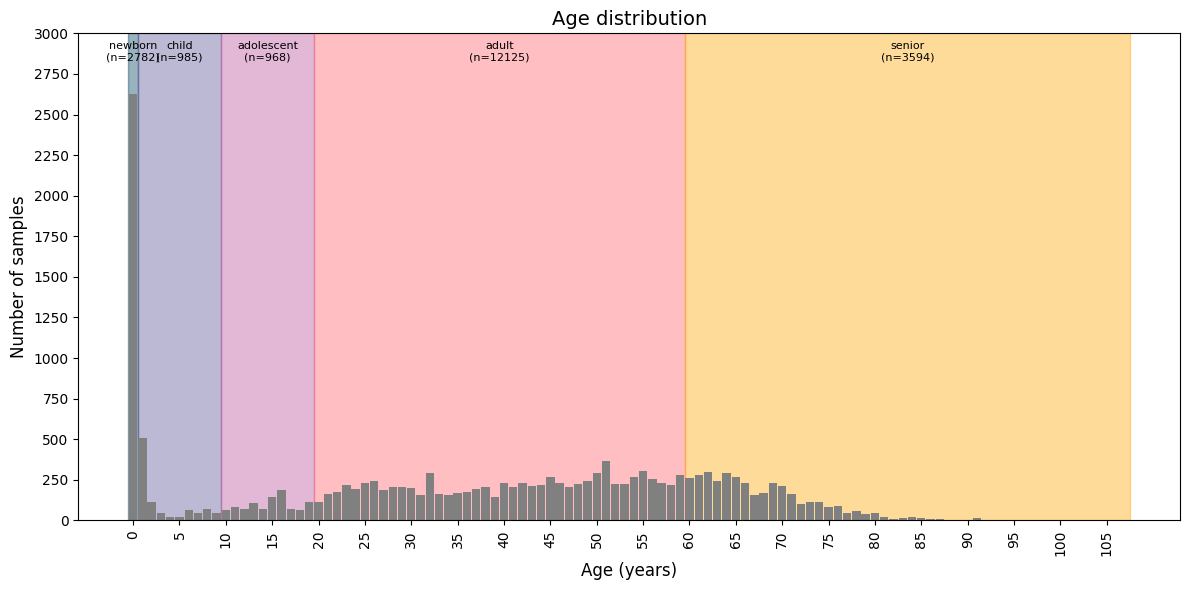

In [12]:
# 1. Prepare age table with age category
age_table = (metadata['age']
             .value_counts()
             .sort_index()
             .rename_axis('age')
             .reset_index(name='count'))

age_table['pct'] = (age_table['count'] / age_table['count'].sum() * 100).round(1)

category_order = ['newborn', 'child', 'adolescent', 'adult', 'senior']

age_category_table = (
    metadata
    .dropna(subset=['age_category'])
    .groupby('age_category')
    .agg(
        count=('age_category', 'size'),
        min_age=('age', 'min'),
        max_age=('age', 'max')
    )
    .reindex(category_order)
    .reset_index()
)

age_category_table['pct'] = (age_category_table['count'] / age_category_table['count'].sum() * 100).round(1)

# 2. PLOT
fig, ax = plt.subplots(figsize=(12, 6))

category_colors = {
    'newborn': '#003f5c',
    'child': '#575092',
    'adolescent': '#bb4e99',
    'adult': '#ff5f68',
    'senior': '#ffa600'
}

max_count = age_table['count'].max()

for _, row in age_category_table.dropna(subset=['min_age', 'max_age']).iterrows():
    ax.axvspan(
        row['min_age'] - 0.5,
        row['max_age'] + 0.5,
        ymin=0,
        ymax=1,
        color=category_colors[row['age_category']],
        alpha=0.4
    )

    # Category label
    ax.text(
        (row['min_age'] + row['max_age']) / 2,
        max_count * 1.10,
        f'{row['age_category']}\n(n={int(row['count'])})',
        ha='center',
        va='center',
        fontsize=8
    )

# Foreground
ax.bar(
    age_table['age'],
    age_table['count'],
    width=0.9,
    color='gray'
)

# Axis labels 
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Number of samples', fontsize=12)
ax.set_title('Age distribution', fontsize=14)

# Axis sep
ax.set_xticks(range(0, 108, 5))
ax.set_yticks(range(0, 3001, 250))

ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.savefig('../images/age_distribution.png', dpi=300)
plt.show()

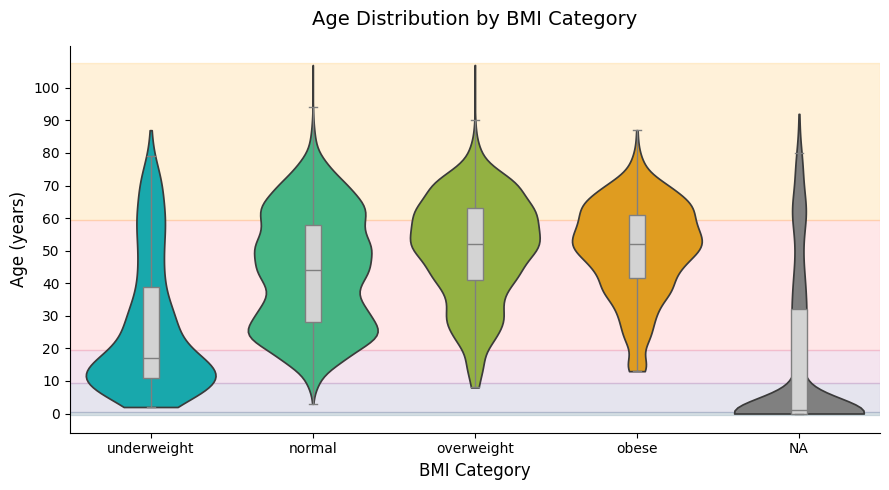

In [15]:
# 1. Prepare BMI table with BMI category
metadata['BMI_category'] = pd.cut(metadata['BMI'],bins=[-float('inf'), 18.5, 25, 30, float('inf')],
    labels=['underweight', 'normal', 'overweight', 'obese'],
    right=False
)

metadata['BMI_category'] = (metadata['BMI_category'].cat.add_categories('NA').fillna('NA'))

bmi_category = ['underweight', 'normal','overweight','obese','NA']

bmi_category_table = (metadata['BMI_category']
                      .value_counts()
                      .reindex(bmi_category)
                      .fillna(0)
                      .astype(int)
                      .rename_axis('BMI_category')
                      .reset_index(name='n_samples'))

# 2. PLOT
plot_data = metadata.dropna(subset=['age']).copy()

bmi_colors = {
    'underweight': '#00bfc4',
    'normal': '#33c886',
    'overweight': '#9bc330',
    'obese': '#ffa600',
    'NA': 'grey'
}

fig, ax = plt.subplots(figsize=(9, 5))

sns.violinplot(
    data=plot_data,
    x='BMI_category',
    y='age',
    order=bmi_category,
    hue='BMI_category',
    palette=bmi_colors,
    inner=None,
    cut=0,
    legend=False,
    ax=ax)

sns.boxplot(
    data=plot_data,
    x='BMI_category',
    y='age',
    order=bmi_category,
    width=0.1,
    color='lightgray',
    fliersize=0,
    ax=ax)

# Backgorund
age_colors = {
    'newborn': '#003f5c',
    'child': '#575092',
    'adolescent': '#bb4e99',
    'adult': '#ff5f68',
    'senior': '#ffa600'}

for _, row in age_category_table.dropna(
    subset=['min_age', 'max_age']
).iterrows():

    ax.axhspan(
        row['min_age'] - 0.5,
        row['max_age'] + 0.5,
        color=age_colors[row['age_category']],
        alpha=0.15,
        zorder=0
    )
ax.set_xlabel('BMI Category', fontsize=12)
ax.set_ylabel('Age (years)', fontsize=12)

# AXIS LABELS
ax.set_title('Age Distribution by BMI Category',
    fontsize=14,
    pad=15)

ax.set_xlabel('BMI Category', fontsize=12)
ax.set_ylabel('Age (years)', fontsize=12)

ax.set_yticks(range(0, 108, 10))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.savefig('../images/BMI.png', dpi=300, bbox_inches='tight')

plt.show()

Non-Western: 3,887 samples (19.0%)
Western: 16,568 samples (81.0%)


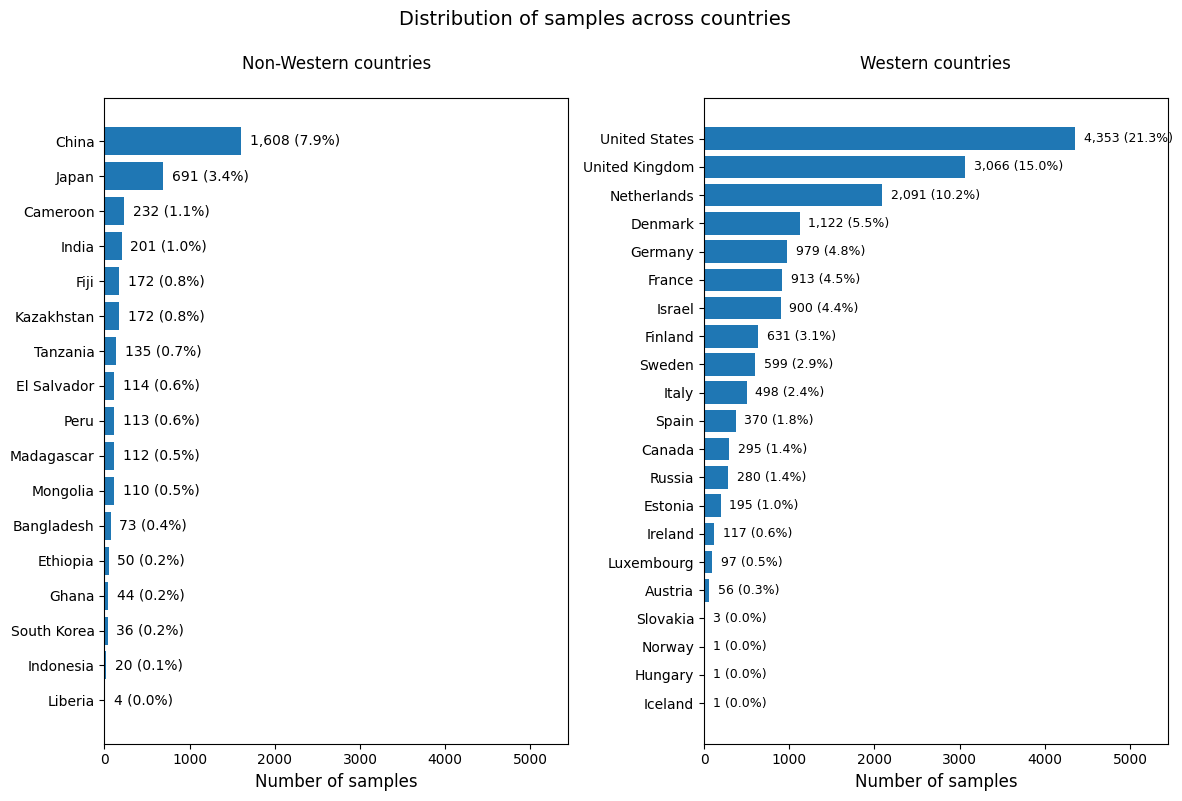

In [16]:
western_countries = [
    'ITA', 'USA', 'GBR', 'SWE', 'DEU', 'AUT', 'CAN', 'DNK', 'RUS',
    'LUX', 'FRA', 'NOR', 'SVK', 'HUN', 'EST', 'FIN', 'ISL',
    'IRL', 'ESP', 'NLD', 'ISR'
]

non_western_countries = [
    'FJI', 'CHN', 'KAZ', 'BGD', 'IND', 'MNG', 'CMR', 'PER',
    'MDG', 'SLV', 'TZA', 'IDN', 'LBR', 'GHA', 'ETH', 'JPN', 'KOR'
]

country_names = {
    'ITA': 'Italy',
    'USA': 'United States',
    'GBR': 'United Kingdom',
    'SWE': 'Sweden',
    'DEU': 'Germany',
    'FJI': 'Fiji',
    'CHN': 'China',
    'KAZ': 'Kazakhstan',
    'BGD': 'Bangladesh',
    'IND': 'India',
    'AUT': 'Austria',
    'CAN': 'Canada',
    'DNK': 'Denmark',
    'LUX': 'Luxembourg',
    'FRA': 'France',
    'NOR': 'Norway',
    'SVK': 'Slovakia',
    'HUN': 'Hungary',
    'EST': 'Estonia',
    'FIN': 'Finland',
    'ISL': 'Iceland',
    'IRL': 'Ireland',
    'ESP': 'Spain',
    'NLD': 'Netherlands',
    'MNG': 'Mongolia',
    'CMR': 'Cameroon',
    'PER': 'Peru',
    'MDG': 'Madagascar',
    'SLV': 'El Salvador',
    'TZA': 'Tanzania',
    'IDN': 'Indonesia',
    'LBR': 'Liberia',
    'GHA': 'Ghana',
    'ETH': 'Ethiopia',
    'JPN': 'Japan',
    'RUS': 'Russia',
    'KOR': 'South Korea',
    'ISR': 'Israel'
}

# Prepare table with COUNTRIES
country_counts = (metadata['country']
                  .value_counts(dropna=False)
                  .rename_axis('country')
                  .reset_index(name='n_samples')
                  )

total_samples = len(metadata)

country_counts['percentage'] = country_counts['n_samples'] / total_samples * 100

# full country names
country_counts['country_name'] = (country_counts['country'].map(country_names))

# Group num. 1: non-western
non_western = (country_counts[country_counts['country'].isin(non_western_countries)]
               .sort_values('n_samples', ascending=True))
non_western_n = metadata['country'].isin(non_western_countries).sum()
non_western_pct = non_western_n / total_samples * 100

# Group num. 2: western
western = (country_counts[country_counts['country'].isin(western_countries)]
               .sort_values('n_samples', ascending=True))
western_n = metadata['country'].isin(western_countries).sum()
western_pct = western_n / total_samples * 100

print(f'Non-Western: {non_western_n:,} samples ({non_western_pct:.1f}%)')
print(f'Western: {western_n:,} samples ({western_pct:.1f}%)')

# PLOT
fig, axes = plt.subplots(1, 2, figsize=(12, 8), sharex=True)

# PLOT: Group num. 1: non-western
axes[0].barh(
    non_western['country_name'],
    non_western['n_samples'],
    zorder=2
)

axes[0].set_title(
    'Non-Western countries\n',
    fontsize=12
)

axes[0].set_xlabel('Number of samples', fontsize=12)

# Add count + percentage to bars
for _, row in non_western.iterrows():
    axes[0].text(
        row['n_samples'] + total_samples * 0.005,
        row['country_name'],
        f'{row['n_samples']:,} ({row['percentage']:.1f}%)',
        va='center',
        fontsize=10
    )

# PLOT: Group num. 2: western
axes[1].barh(
    western['country_name'],
    western['n_samples'],
    zorder=2
)

axes[1].set_title('Western countries\n', fontsize=12)

axes[1].set_xlabel('Number of samples', fontsize=12)
axes[1].set_ylabel('')

# Add count + percentage to bars
for _, row in western.iterrows():
    axes[1].text(
        row['n_samples'] + total_samples * 0.005,
        row['country_name'],
        f'{row['n_samples']:,} ({row['percentage']:.1f}%)',
        va='center',
        fontsize=9
    )

# LABELS
max_count = country_counts['n_samples'].max()

axes[0].set_xlim(0, max_count * 1.25)
axes[1].set_xlim(0, max_count * 1.25)

plt.suptitle('Distribution of samples across countries',
    fontsize=14,
    y=0.995
)

plt.tight_layout()
plt.savefig('../images/countries.png', dpi=300)
plt.show()